In [1]:
from baja.sample_data import load_cubs_traj_data
import numpy as np
import matplotlib.pyplot as plt
import rerun as rr


In [2]:
df = load_cubs_traj_data("0.1s")[:200]
# df = pd.read_parquet("../data/cub_sample_traj.parquet")
seq_len = len(df)
df


,x,y,z
timestamp,,,
2025-11-13 22:32:49.920561822,5.777766,-1.627579,2.306062
2025-11-13 22:32:50.020561822,5.674212,-1.987511,2.383517
2025-11-13 22:32:50.120561822,5.568074,-2.334517,2.453512
2025-11-13 22:32:50.220561822,5.456122,-2.685332,2.517932
2025-11-13 22:32:50.320561822,5.346367,-3.024120,2.570787
...,...,...,...
2025-11-13 22:33:09.420561822,-6.238126,-4.846046,1.476847
2025-11-13 22:33:09.520561822,-6.408151,-4.427960,1.464611
2025-11-13 22:33:09.620561822,-6.549445,-4.008885,1.453578


In [3]:
ts = df.index.to_numpy().astype(np.datetime64)
target_pos = df[["x", "y", "z"]].to_numpy()
rng = np.random.default_rng(12345)
n_points = 50
offsets = rng.normal(scale=0.5, size=(n_points, seq_len, 3))
radii = rng.uniform(0.1, 0.3, size=[seq_len, n_points])
cloud = target_pos + offsets
B, T, D = cloud.shape

sensor_pos = np.array(
    [
        [20, 5, 10],
        [20, -5, 10],
        [-5, 5, 10],
        [-5, -5, 10],
    ]
)
# sensor_pos = np.expand_dims(sensor_pos, 1)
dist_meas = np.linalg.norm((target_pos - sensor_pos[:, None, :]), axis=-1)
bearing_meas = (target_pos - sensor_pos[:, None, :]) / dist_meas[..., None]

In [4]:
b_vec = bearing_meas[:, 0, :]
b1 = b_vec[0]
angle1 = np.acos(b1[-1] / np.linalg.norm(b1))
elev1 = np.pi / 2 - angle1
np.rad2deg(elev1)


np.float64(-26.121094373911916)

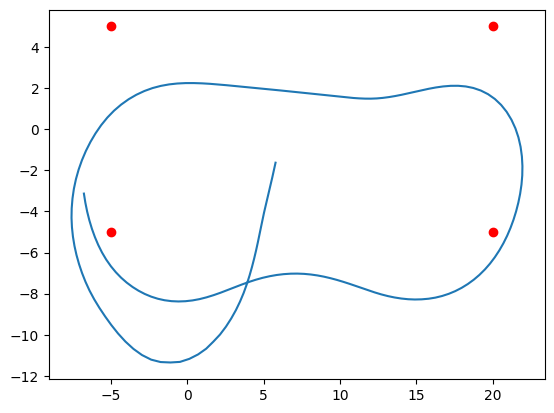

In [5]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(df.x, df.y)
ax.scatter(sensor_pos[..., 0], sensor_pos[..., 1], c="r")

In [13]:
rr.init("traj_vis")
# rr.connect_grpc()
time = rr.TimeColumn("time", timestamp=ts)
rr.log(
    "sensors/location",
    rr.Points3D(positions=sensor_pos, radii=[0.2] * 4),
    static=True,
    strict=True,
)
rr.log(
    "traj/line",
    rr.LineStrips3D(strips=target_pos, radii=[0.05], colors=[0x43AAFFC3]),
    static=True,
    strict=True,
)

rr.send_columns(
    "traj/true",
    indexes=[time],
    columns=[
        *rr.Points3D.columns(
            positions=target_pos, radii=[0.5] * seq_len, colors=[(255, 0, 0)] * seq_len
        )
    ],
)

rr.send_columns(
    "sensors/bearing",
    indexes=[time],
    columns=[
        *rr.Arrows3D.columns(
            vectors=bearing_meas.transpose(1, 0, 2).reshape(-1, 3) * 2,
            origins=np.tile(sensor_pos, (1, seq_len, 1))
            .transpose(1, 0, 2)
            .reshape(-1, 3),
        ).partition([4] * seq_len),
    ],
)
rr.send_columns(
    "sensors/range",
    indexes=[time],
    columns=[
        *rr.Points3D.columns(
            positions=np.tile(sensor_pos, (1, seq_len, 1))
            .transpose(1, 0, 2)
            .reshape(-1, 3),
            radii=dist_meas.transpose().reshape(-1),
            colors=[0x43ff644d] * 4*seq_len,
        ).partition([4] * seq_len)
    ],
)

# rr.send_columns(
#     "traj/cloud",
#     indexes=[rr.TimeColumn("time", timestamp=ts)],
#     columns=[
#         *rr.Points3D.columns(
#             positions=cloud.transpose(1, 0, 2).reshape((-1, 3)),
#             radii=radii.reshape((-1)),
#         ).partition([n_points] * seq_len),
#     ],
# )

rr.notebook_show()

HTML(value='<div id="643b313c-06ec-4309-b131-20fec96d36e6"><style onload="eval(atob(\'KGFzeW5jIGZ1bmN0aW9uICgp…

In [21]:
from baja import pf, ekf, ukf, pff
import jax.numpy as jnp
import jax.random as jr


def dynamics_fn(states):
    dt = 0.1
    A = np.block([[np.eye(3), dt * np.eye(3)], [np.zeros((3, 3)), np.eye(3)]])
    return (A @ states.T).T


def dist_meas_fn(states):
    pos = states[:3]
    sensor_pos = np.array(
        [
            [20, 5, 10],
            [20, -5, 10],
            [-5, 5, 10],
            [-5, -5, 10],
        ]
    )
    dist_meas = jnp.linalg.norm(pos - sensor_pos, axis=-1)
    return dist_meas


def bearing_meas_fn(states):
    pos = states[:3]
    sensor_pos = np.array(
        [
            [20, 5, 10],
            [20, -5, 10],
            [-5, 5, 10],
            [-5, -5, 10],
        ]
    )
    dist_meas = jnp.linalg.norm(pos - sensor_pos, axis=-1)
    bearing = (pos - sensor_pos) / dist_meas[:, None]
    return bearing.flatten()


key = jr.key(111)

n_particles = 10000
init_state = np.hstack(
    [
        rng.normal(target_pos[0], size=(n_particles, 3)),
        np.random.uniform(-1, 1, (n_particles, 3)),
    ]
)

particles = pf.ParticleState(init_state, np.ones(n_particles), key)
Q = np.diag([1e-1, 1e-1, 1e-1, 0.5, 0.5, 0.5])
R = np.eye(4) * 0.1
filter = pf.ParticleFilter(
    f=dynamics_fn,
    # h=bearing_meas_fn,
    h=dist_meas_fn,
    num_particles=n_particles,
    Q=Q,
    R=R,
)

n_particles = 10
init_state = np.hstack(
    [
        rng.normal(target_pos[0], size=(n_particles, 3)),
        np.random.uniform(-1, 1, (n_particles, 3)),
    ]
)
particles2 = pff.ParticleState(init_state, np.ones(n_particles), key)
filter2 = pff.EDHFilter(
    f=dynamics_fn, h=dist_meas_fn, num_particles=n_particles, Q=Q, R=R
)

In [22]:
rr.init("traj_vis")
particle_hist = []
particle_hist.append(particles)

particle2_hist = []
particle2_hist.append(particles2)

rr.log(
    "sensors/location",
    rr.Points3D(positions=sensor_pos, radii=[0.2] * 4),
    static=True,
    strict=True,
)
rr.log(
    "traj/line",
    rr.LineStrips3D(strips=target_pos, radii=[0.05], colors=[0x43AAFFC3]),
    static=True,
    strict=True,
)

rr.log("traj/cloud", rr.Points3D(positions=particles.particles[:, :3]))
rr.log("traj/cloud2", rr.Points3D(positions=particles2.particles[:, :3]))
# rr.log("ekf_est", rr.Points3D(positions=state.mean[:3]))

for i in range(seq_len):
    key, other_key = jr.split(key)
    dist_noisy = dist_meas[..., i] + jr.normal(key=other_key, shape=(4,)) * 0.1
    # bearing_noisy = bearing_meas[:, i, :].flatten() + jr.normal(
    #     key=other_key, shape=(12,)
    # )
    particles_pred = filter.predict(particles)
    particles = filter.update(particles_pred, dist_noisy)
    particle_hist.append(particles)

    particles2_pred = filter2.predict(particles2)
    particles2 = filter2.update(particles2_pred, dist_noisy)
    particle2_hist.append(particles2)

    rr.log("traj/cloud", rr.Points3D(positions=particles.particles[:, :3]))
    rr.log("traj/cloud2", rr.Points3D(positions=particles2.particles[:, :3]))

    rr.log(
        "traj/true",
        rr.Points3D(positions=target_pos[i, :], radii=[0.1], colors=[(255, 0, 0)]),
    )
    # state_pred = filter2.predict(state)
    # state = filter2.update(state, dist_noisy)
    # state_hist.append(state)
    # rr.log("ekf_est", rr.Points3D(positions=state.mean[:3]))
rr.notebook_show(width=960, height=720)

HTML(value='<div id="5b5a0884-238a-4a0d-ad99-1e0ae5ab0dce"><style onload="eval(atob(\'KGFzeW5jIGZ1bmN0aW9uICgp…

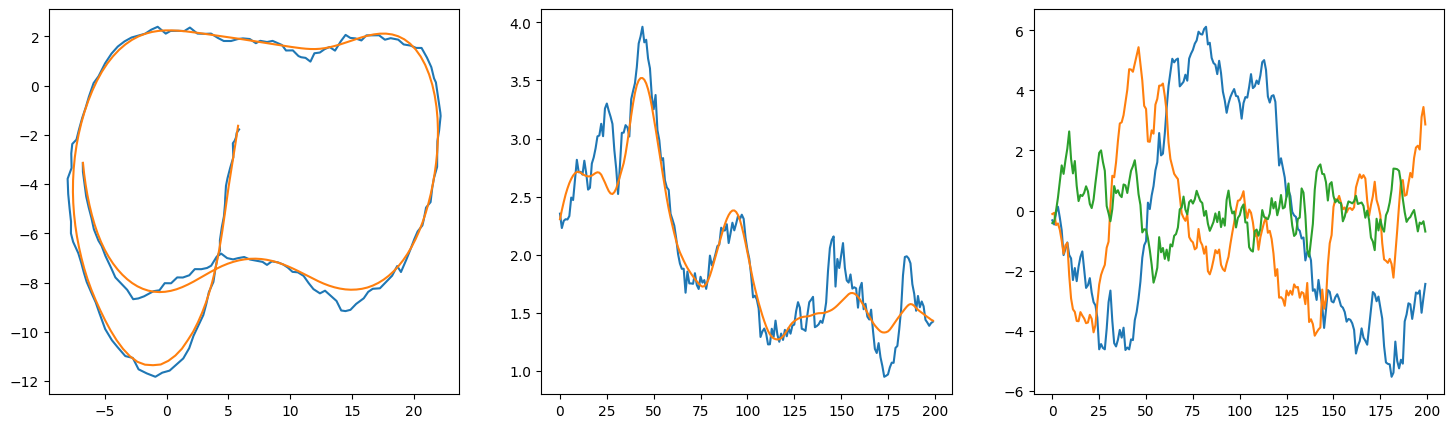

In [18]:
means = np.array([p.mean for p in particle2_hist])

# means = np.array([s.mean for s in state_hist])

fig = plt.figure(figsize=(18, 5))
axs = fig.subplots(1, 3).flatten()
axs[0].plot(means[1:, 0], means[1:, 1])
axs[0].plot(target_pos[..., 0], target_pos[..., 1])

axs[1].plot(means[1:, 2])
axs[1].plot(target_pos[..., 2])

axs[2].plot(means[1:, 3:])
# axs[1].plot(means[1:, 4])